In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re

def parse_carla_data(data_string, model_name):
    """
    Parse CARLA data string and return a DataFrame.
    
    Args:
        data_string (str): Multi-line string with CARLA metrics data
        model_name (str): Name of the model for the 'Model' column
    
    Returns:
        pd.DataFrame: Parsed data with columns for Model, FPS, and metric means/stds
    """
    lines = data_string.strip().split('\n')
    
    results = []
    current_fps = None
    fps_data = []
    
    for line in lines:
        line = line.strip()
        if not line:
            continue
        
        # Split by tabs first, then by spaces to handle both formats
        parts = line.split('\t') if '\t' in line else line.split()
        parts = [p.strip() for p in parts if p.strip()]  # Remove empty strings
        
        if not parts:
            continue
            
        # Skip header line
        if parts[0] == 'FPS':
            continue
            
        # Skip AVERAGE and STDEV lines
        if parts[0] in ['AVERAGE', 'STDEV']:
            continue
            
        try:
            # Check if first column is a number (could be FPS or seed)
            first_val = int(parts[0])
            
            # If we have 6 parts: FPS, Seed, SR, DS, RC, IS
            if len(parts) >= 6:
                # This is a new FPS group starting
                # Save previous FPS data if exists
                if current_fps is not None and fps_data:
                    sr_vals = [d['SR'] for d in fps_data]
                    ds_vals = [d['DS'] for d in fps_data]
                    rc_vals = [d['RC'] for d in fps_data]
                    is_vals = [d['IS'] for d in fps_data]
                    
                    results.append({
                        'Model': model_name,
                        'FPS': current_fps,
                        'SR_mean': np.mean(sr_vals),
                        'SR_std': np.std(sr_vals, ddof=1) if len(sr_vals) > 1 else 0,
                        'DS_mean': np.mean(ds_vals),
                        'DS_std': np.std(ds_vals, ddof=1) if len(ds_vals) > 1 else 0,
                        'RC_mean': np.mean(rc_vals),
                        'RC_std': np.std(rc_vals, ddof=1) if len(rc_vals) > 1 else 0,
                        'IS_mean': np.mean(is_vals),
                        'IS_std': np.std(is_vals, ddof=1) if len(is_vals) > 1 else 0,
                    })
                
                # Start new FPS group
                current_fps = first_val
                fps_data = [{
                    'SR': float(parts[2]),
                    'DS': float(parts[3]),
                    'RC': float(parts[4]),
                    'IS': float(parts[5])
                }]
                
            # If we have 5 parts and current_fps exists: Seed, SR, DS, RC, IS
            elif len(parts) >= 5 and current_fps is not None:
                fps_data.append({
                    'SR': float(parts[1]),
                    'DS': float(parts[2]),
                    'RC': float(parts[3]),
                    'IS': float(parts[4])
                })
                
        except (ValueError, IndexError):
            # Handle lines that start with empty cells (continuation of same FPS)
            # These would be like: "", "1", "60", "67.95", "80.392", "0.817"
            if len(parts) >= 5:
                try:
                    # Try to parse as seed data: seed, SR, DS, RC, IS
                    if current_fps is not None:
                        fps_data.append({
                            'SR': float(parts[1]),
                            'DS': float(parts[2]),
                            'RC': float(parts[3]),
                            'IS': float(parts[4])
                        })
                except (ValueError, IndexError):
                    continue
    
    # Don't forget the last FPS group
    if current_fps is not None and fps_data:
        sr_vals = [d['SR'] for d in fps_data]
        ds_vals = [d['DS'] for d in fps_data]
        rc_vals = [d['RC'] for d in fps_data]
        is_vals = [d['IS'] for d in fps_data]
        
        results.append({
            'Model': model_name,
            'FPS': current_fps,
            'SR_mean': np.mean(sr_vals),
            'SR_std': np.std(sr_vals, ddof=1) if len(sr_vals) > 1 else 0,
            'DS_mean': np.mean(ds_vals),
            'DS_std': np.std(ds_vals, ddof=1) if len(ds_vals) > 1 else 0,
            'RC_mean': np.mean(rc_vals),
            'RC_std': np.std(rc_vals, ddof=1) if len(rc_vals) > 1 else 0,
            'IS_mean': np.mean(is_vals),
            'IS_std': np.std(is_vals, ddof=1) if len(is_vals) > 1 else 0,
        })
    
    return pd.DataFrame(results)

In [2]:
def plot_carla_results(df, title="Effect of Framerate on CARLA NoCrash Metrics"):
    """
    Plot CARLA results for multiple models with specific styling:
    - Color indicates guidance (red for baseline, blue for guided)
    - Line style indicates resolution (solid for 400x225, dotted for 960x540)
    - Different shaded area patterns to distinguish overlapping models
    
    Args:
        df (pd.DataFrame): DataFrame with Model, FPS, and metric columns
        title (str): Main title for the plot
    """
    # Set up the plot style
    plt.style.use('default')
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle(title, fontsize=16, fontweight='bold')

    # Define colors for guidance with slightly different shades for clarity
    guidance_colors = {
    'baseline': {'400x225': '#d8031c', '960x540': '#d8031c'},  # Same red
    'guided': {'400x225': '#1f77b4', '960x540': '#1f77b4'}     # Same blue
    }
    
    # Categorize models
    def get_model_properties(model_name):
        # Determine resolution
        if '400x225' in model_name:
            resolution = '400x225'
        elif '960x540' in model_name:
            resolution = '960x540'
        else:
            resolution = 'Unknown'
        
        # Determine if guided
        is_guided = 'Guided' in model_name or 'guided' in model_name
        guidance = 'guided' if is_guided else 'baseline'
        
        return resolution, guidance
    
    models = df['Model'].unique()
    metrics = ['SR', 'DS', 'RC', 'IS']
    metric_names = ['Success Rate (%)', 'Driving Score', 'Route Completion (%)', 'Infraction Score']

    # Plot each metric
    for i, (metric, name) in enumerate(zip(metrics, metric_names)):
        row = i // 2
        col = i % 2
        ax = axes[row, col]
        
        mean_col = f'{metric}_mean'
        std_col = f'{metric}_std'
        
        # Plot each model
        for model in models:
            model_data = df[df['Model'] == model].sort_values('FPS')
            resolution, guidance = get_model_properties(model)
            
            color = guidance_colors[guidance][resolution]
            linestyle = '-' if resolution == '400x225' else '--'
            linewidth = 2.5
            
            # Different hatching patterns for shaded areas
            if guidance == 'guided' and resolution == '400x225':
                alpha_fill = 0.2
                hatch = None
            elif guidance == 'guided' and resolution == '960x540':
                alpha_fill = 0.15
                hatch = '///'
            elif guidance == 'baseline' and resolution == '400x225':
                alpha_fill = 0.2
                hatch = None
            else:  # baseline 960x540
                alpha_fill = 0.15
                hatch = '\\\\\\'
            
            fps_vals = model_data['FPS'].values
            mean_vals = model_data[mean_col].values
            std_vals = model_data[std_col].values
            
            # Plot main line
            ax.plot(fps_vals, mean_vals, color=color, linestyle=linestyle, 
                   linewidth=linewidth, marker='o', markersize=6)
            
            # Plot shaded standard deviation area with hatching
            ax.fill_between(fps_vals, mean_vals - std_vals, mean_vals + std_vals, 
                           color=color, alpha=alpha_fill, hatch=hatch, edgecolor=color, linewidth=0)
        
        # Customize each subplot
        ax.set_xlabel('Framerate (FPS)', fontsize=12)
        ax.set_ylabel(name, fontsize=12)
        ax.set_title(f'{name} vs. Framerate', fontsize=13, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(sorted(df['FPS'].unique()))
        
        # Add legend only to the first subplot
        if i == 0:
            from matplotlib.lines import Line2D
            from matplotlib.patches import Patch
            legend_elements = [
                Line2D([0], [0], color='#d8031c', linewidth=2.5, label='Baseline'),
                Line2D([0], [0], color='#1f77b4', linewidth=2.5, label='Guided'),
                Line2D([0], [0], color='black', linewidth=0, label=''),  # Spacer
                Line2D([0], [0], color='black', linestyle='-', linewidth=2, label='400×225'),
                Line2D([0], [0], color='black', linestyle='--', linewidth=2, label='960×540'),
                Line2D([0], [0], color='black', linewidth=0, label=''),  # Spacer
                Patch(facecolor='gray', alpha=0.2),
                Patch(facecolor='gray', alpha=0.15, hatch='///')
            ]
            
            ax.legend(handles=legend_elements, 
                     labels=['Baseline', 'Guided', '', '400×225', '960×540'],
                     loc='lower left', fontsize=9, framealpha=0.9)
            
    # Adjust layout and show
    plt.tight_layout()
    plt.subplots_adjust(top=0.93)
    plt.show()

In [3]:
data_string_cpp = """
FPS	Seed	SR	DS	RC	IS
10	0	68	73.49	83.094	0.858
	1	60	67.95	80.392	0.817
	2	72	74.149	86.325	0.826
	AVERAGE	66.6667	71.8630	83.2703	0.8337
	STDEV	6.1101	3.4047	2.9704	0.0215
					
20	0	60	61.404	79.189	0.725
	1	56	69.001	76.788	0.841
	2	76	78.074	90.015	0.828
	AVERAGE	64.0000	69.4930	81.9973	0.7980
	STDEV	10.5830	8.3459	7.0465	0.0636
					
30	0	44	57.93	70.955	0.768
	1	32	50.386	63.418	0.736
	2	56	59.46	70.665	0.762
	AVERAGE	44.0000	55.9253	68.3460	0.7553
	STDEV	12.0000	4.8578	4.2702	0.0170
					
40	0	40	52.791	68.528	0.728
	1	20	42.849	58.719	0.666
	2	36	43.958	60.999	0.689
	AVERAGE	32.0000	46.5327	62.7487	0.6943
	STDEV	10.5830	5.4482	5.1332	0.0313
					
50	0	36	50.358	66.516	0.705
	1	36	54.977	66.454	0.779
	2	40	53.045	66.695	0.729
	AVERAGE	37.3333	52.7933	66.5550	0.7377
	STDEV	2.3094	2.3198	0.1251	0.0378
					
60	0	28	47.197	63.684	0.7
	1	32	46.715	60.325	0.713
	2	24	43.662	57.683	0.682
	AVERAGE	28.0000	45.8580	60.5640	0.6983
	STDEV	4.0000	1.9170	3.0076	0.0156
 
120	0	12	27.397	39.4	0.629
	1	28	43.494	57.928	0.692
	2	20	37.138	52.172	0.666
	AVERAGE	20.0000	36.0097	49.8333	0.6623
	STDEV	8.0000	8.1076	9.4828	0.0317"""

data_string_cpp_guided = """
FPS	Seed	SR	DS	RC	IS
10	0	88	90.24	97.44	0.928
	1	76	80.587	89.976	0.862
	2	76	78.897	91.197	0.864
	AVERAGE	80.0000	83.2413	92.8710	0.8847
	STDEV	6.9282	6.1196	4.0037	0.0375
					
20	0	76	79.953	89.454	0.864
	1	88	90.189	94.213	0.943
	2	80	80.1	90.899	0.87
	AVERAGE	81.3333	83.4140	91.5220	0.8923
	STDEV	6.1101	5.8678	2.4399	0.0440
					
30	0	76	78.294	91.41	0.831
	1	72	75.038	86.633	0.828
	2	80	80.37	95.596	0.834
	AVERAGE	76.0000	77.9007	91.2130	0.8310
	STDEV	4.0000	2.6877	4.4847	0.0030
					
40	0	100	90.297	100	0.903
	1	76	80.015	85.789	0.893
	2	76	79.857	94.075	0.836
	AVERAGE	84.0000	83.3897	93.2880	0.8773
	STDEV	13.8564	5.9824	7.1381	0.0361
					
50	0	92	88.936	96.146	0.913
	1	80	79.669	91.338	0.864
	2	96	90.625	96.441	0.928
	AVERAGE	89.3333	86.4100	94.6417	0.9017
	STDEV	8.3267	5.8986	2.8649	0.0335
					
60	0	84	81.465	92.541	0.861
	1	84	78.11	93.119	0.815
	2	88	89.191	94.793	0.928
	AVERAGE	85.3333	82.9220	93.4843	0.8680
	STDEV	2.3094	5.6824	1.1696	0.0568
 
120	0	84	86.81	92.154	0.922
	1	80	85.516	93.333	0.896
	2	76	84.463	90.786	0.912
	AVERAGE	80.0000	85.5963	92.0910	0.9100
	STDEV	4.0000	1.1756	1.2747	0.0131"""
 
data_string_cpp_hres = """
 FPS	Seed	SR	DS	RC	IS
10	0	84	88.685	96.355	0.914
	1	64	78.3	87.164	0.867
	2	68	81.125	93.329	0.862
	AVERAGE	72.0000	82.7033	92.2827	0.8810
	STDEV	10.5830	5.3694	4.6840	0.0287
					
20	0	84	79.513	92.266	0.841
	1	60	72.121	80.24	0.84
	2	72	77.415	90.005	0.854
	AVERAGE	72.0000	76.3497	87.5037	0.8450
	STDEV	12.0000	3.8094	6.3913	0.0078
					
30	0	64	70.449	79.042	0.868
	1	60	66.59	77.342	0.786
	2	64	73.072	86.402	0.841
	AVERAGE	62.6667	70.0370	80.9287	0.8317
	STDEV	2.3094	3.2606	4.8157	0.0418
					
40	0	52	59.008	72.138	0.77
	1	64	69.887	80.135	0.813
	2	64	66.025	82.075	0.766
	AVERAGE	60.0000	64.9733	78.1160	0.7830
	STDEV	6.9282	5.5152	5.2672	0.0261
					
50	0	56	64.775	80.992	0.755
	1	44	58.134	74.286	0.721
	2	52	65.585	78.46	0.823
	AVERAGE	50.6667	62.8313	77.9127	0.7663
	STDEV	6.1101	4.0881	3.3863	0.0519
					
60	0	44	57.91	69.917	0.781
	1	52	60.971	75.281	0.79
	2	56	59.056	72.232	0.759
	AVERAGE	50.6667	59.3123	72.4767	0.7767
	STDEV	6.1101	1.5465	2.6904	0.0159
 
120	0	56	62.396	75.221	0.769
	1	40	48.389	64.02	0.7
	2	52	63.656	74.545	0.807
	AVERAGE	49.3333	58.1470	71.2620	0.7587
	STDEV	8.3267	8.4741	6.2809	0.0542"""
 
data_string_cpp_hres_guided = """
 FPS	Seed	SR	DS	RC	IS
10	0	76	81.902	90.571	0.885
	1	88	85.733	95.954	0.88
	2	72	81.047	92.261	0.866
	AVERAGE	78.6667	82.8940	92.9287	0.8770
	STDEV	8.3267	2.4955	2.7529	0.0098
					
20	0	96	90.805	96.741	0.928
	1	88	91.077	97.621	0.932
	2	88	91.128	98.213	0.924
	AVERAGE	90.6667	91.0033	97.5250	0.9280
	STDEV	4.6188	0.1736	0.7407	0.0040
					
30	0	88	89.952	97.887	0.914
	1	80	79.929	89.25	0.859
	2	88	82.271	95.345	0.846
	AVERAGE	85.3333	84.0507	94.1607	0.8730
	STDEV	4.6188	5.2431	4.4386	0.0361
					
40	0	88	87.627	95.708	0.901
	1	72	78.816	88.878	0.862
	2	92	86.694	96.223	0.89
	AVERAGE	84.0000	84.3790	93.6030	0.8843
	STDEV	10.5830	4.8402	4.1001	0.0201
					
50	0	96	91.733	99.253	0.925
	1	92	91.311	95.256	0.948
	2	92	88.901	98.426	0.902
	AVERAGE	93.3333	90.6483	97.6450	0.9250
	STDEV	2.3094	1.5279	2.1099	0.0230
					
60	0	80	85.948	91.079	0.929
	1	88	84.315	96.832	0.866
	2	76	77.375	86.641	0.868
	AVERAGE	81.3333	82.5460	91.5173	0.8877
	STDEV	6.1101	4.5520	5.1096	0.0358
 
120	0	92	89.429	95.308	0.93
	1	80	81.082	92.639	0.865
	2	76	79.568	86.382	0.885
	AVERAGE	82.6667	83.3597	91.4430	0.8933
	STDEV	8.3267	5.3104	4.5816	0.0333"""

In [4]:
df1 = parse_carla_data(data_string_cpp, "CIL++ - 400x225")
df2 = parse_carla_data(data_string_cpp_guided, "CIL++ Guided - 400x225")
df3 = parse_carla_data(data_string_cpp_hres, "CIL++ - 960x540")
df4 = parse_carla_data(data_string_cpp_hres_guided, "CIL++ Guided - 960x540")

df = pd.concat([df1, df2, df3, df4], ignore_index=True)


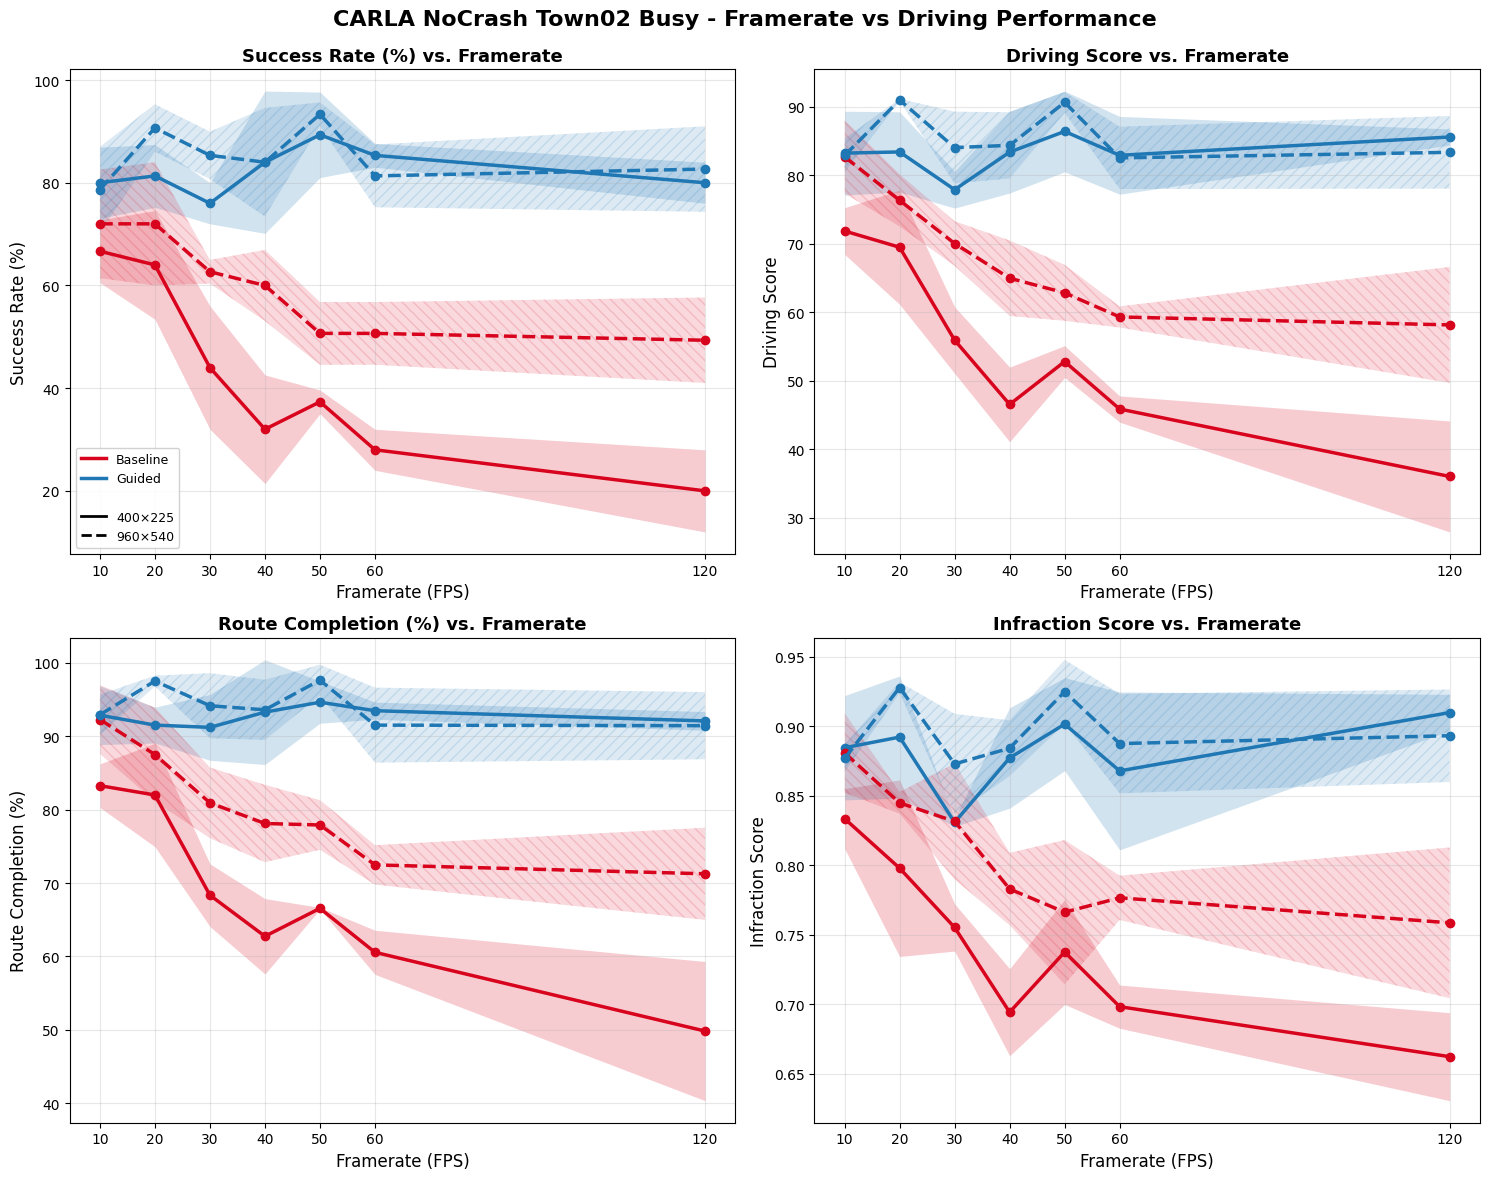

In [6]:
plot_carla_results(df, "CARLA NoCrash Town02 Busy - Framerate vs Driving Performance")

## Longest6

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re

def parse_carla_data(data_string, model_name):
    """
    Parse CARLA data string and return a DataFrame.
    Automatically detects available metrics from the header.
    
    Args:
        data_string (str): Multi-line string with CARLA metrics data
        model_name (str): Name of the model for the 'Model' column
    
    Returns:
        pd.DataFrame: Parsed data with columns for Model, FPS, and metric means/stds
    """
    lines = data_string.strip().split('\n')
    
    # Detect metrics from header
    header_line = None
    for line in lines:
        if 'FPS' in line and 'Seed' in line:
            header_line = line
            break
    
    if header_line is None:
        raise ValueError("Could not find header line with FPS and Seed")
    
    # Parse header to get metric names
    header_parts = header_line.split('\t') if '\t' in header_line else header_line.split()
    header_parts = [p.strip() for p in header_parts if p.strip()]
    
    # Extract metric names (everything after FPS and Seed)
    fps_idx = header_parts.index('FPS')
    seed_idx = header_parts.index('Seed')
    metrics = [h for i, h in enumerate(header_parts) if i > max(fps_idx, seed_idx)]
    
    results = []
    current_fps = None
    fps_data = []
    
    for line in lines:
        line = line.strip()
        if not line:
            continue
        
        # Split by tabs first, then by spaces to handle both formats
        parts = line.split('\t') if '\t' in line else line.split()
        parts = [p.strip() for p in parts if p.strip()]
        
        if not parts:
            continue
            
        # Skip header line
        if parts[0] == 'FPS':
            continue
            
        # Skip AVERAGE and STDEV lines
        if parts[0] in ['AVERAGE', 'STDEV']:
            continue
            
        try:
            # Check if first column is a number (could be FPS or seed)
            first_val = int(parts[0])
            
            # Expected length: FPS + Seed + metrics
            expected_len = 2 + len(metrics)
            
            if len(parts) >= expected_len:
                # This is a new FPS group starting
                # Save previous FPS data if exists
                if current_fps is not None and fps_data:
                    # Calculate means and stds for all metrics
                    result = {'Model': model_name, 'FPS': current_fps}
                    
                    for i, metric in enumerate(metrics):
                        metric_vals = [d[metric] for d in fps_data]
                        result[f'{metric}_mean'] = np.mean(metric_vals)
                        result[f'{metric}_std'] = np.std(metric_vals, ddof=1) if len(metric_vals) > 1 else 0
                    
                    results.append(result)
                
                # Start new FPS group
                current_fps = first_val
                # Parse metric values starting from index 2 (after FPS and Seed)
                metric_dict = {}
                for i, metric in enumerate(metrics):
                    metric_dict[metric] = float(parts[2 + i])
                fps_data = [metric_dict]
                
            # If we have the right length for continuation line and current_fps exists
            elif len(parts) >= (1 + len(metrics)) and current_fps is not None:
                # Parse metric values starting from index 1 (after Seed)
                metric_dict = {}
                for i, metric in enumerate(metrics):
                    metric_dict[metric] = float(parts[1 + i])
                fps_data.append(metric_dict)
                
        except (ValueError, IndexError):
            # Handle lines that start with empty cells (continuation of same FPS)
            if len(parts) >= (1 + len(metrics)):
                try:
                    if current_fps is not None:
                        # Parse metric values starting from index 1 (after Seed)
                        metric_dict = {}
                        for i, metric in enumerate(metrics):
                            metric_dict[metric] = float(parts[1 + i])
                        fps_data.append(metric_dict)
                except (ValueError, IndexError):
                    continue
    
    # Don't forget the last FPS group
    if current_fps is not None and fps_data:
        result = {'Model': model_name, 'FPS': current_fps}
        
        for metric in metrics:
            metric_vals = [d[metric] for d in fps_data]
            result[f'{metric}_mean'] = np.mean(metric_vals)
            result[f'{metric}_std'] = np.std(metric_vals, ddof=1) if len(metric_vals) > 1 else 0
        
        results.append(result)
    
    return pd.DataFrame(results)


In [4]:
data_string_transfuser_longest6 = """
FPS	Seed	DS	RC	IS
10	0	13.853	48.142	0.413
	1	15.728	45.136	0.5
	2	9.897	46.153	0.392
	AVERAGE	13.1593	46.4770	0.4350
	STDEV	2.9767	1.5290	0.0573
				
20	0	44.321	77.478	0.596
	1	41.668	79.774	0.583
	2	50.471	79.5	0.631
	AVERAGE	45.4867	78.9173	0.6033
	STDEV	4.5158	1.2540	0.0248
				
30	0	34.336	84.057	0.422
	1	27.405	74.922	0.435
	2	31.334	86.431	0.365
	AVERAGE	31.0250	81.8033	0.4073
	STDEV	3.4758	6.0765	0.0372

40	0	19.18	67.702	0.359
	1	21.868	82.09	0.294
	2	18.917	79.784	0.245
	AVERAGE	19.9883	76.5253	0.2993
	STDEV	1.6331	7.7277	0.0572"""

In [5]:
df = parse_carla_data(data_string_transfuser_longest6, 'TransFuser')

In [6]:
df

,Model,FPS,DS_mean,DS_std,RC_mean,RC_std,IS_mean,IS_std
0,TransFuser,10,13.159333,2.976747,46.477000,1.528967,0.435000,0.057263
1,TransFuser,20,45.486667,4.515782,78.917333,1.254005,0.603333,0.024826
2,TransFuser,30,31.025000,3.475817,81.803333,6.076474,0.407333,0.037233
3,TransFuser,40,19.988333,1.633142,76.525333,7.727730,0.299333,0.057187


In [7]:
def plot_carla_results(df, title="Effect of Framerate on CARLA NoCrash Metrics"):
    """
    Plot CARLA results for multiple models with specific styling:
    - Color indicates guidance (red for baseline, blue for guided)
    - Line style indicates resolution (solid for 400x225, dotted for 960x540)
    - Different shaded area patterns to distinguish overlapping models
    
    Args:
        df (pd.DataFrame): DataFrame with Model, FPS, and metric columns
        title (str): Main title for the plot
    """
    # Set up the plot style
    plt.style.use('default')
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(title, fontsize=16, fontweight='bold')

    # Define colors for guidance with slightly different shades for clarity
    guidance_colors = {
        'baseline': {'400x225': '#d8031c', '960x540': '#b8021a', 'Unknown': '#0b6623'},  # Red variants
        'guided': {'400x225': '#1f77b4', '960x540': '#1464a0'},    # Blue variants
    }
    
    # Categorize models
    def get_model_properties(model_name):
        # Determine resolution
        if '400x225' in model_name:
            resolution = '400x225'
        elif '960x540' in model_name:
            resolution = '960x540'
        else:
            resolution = 'Unknown'
        
        # Determine if guided
        is_guided = 'Guided' in model_name or 'guided' in model_name
        guidance = 'guided' if is_guided else 'baseline'
        
        return resolution, guidance
    
    models = df['Model'].unique()
    metrics = ['DS', 'RC', 'IS']
    metric_names = ['Driving Score', 'Route Completion (%)', 'Infraction Score']

    # Plot each metric
    for i, (metric, name) in enumerate(zip(metrics, metric_names)):
        ax = axes[i]
        
        mean_col = f'{metric}_mean'
        std_col = f'{metric}_std'
        
        # Plot each model
        for model in models:
            model_data = df[df['Model'] == model].sort_values('FPS')
            resolution, guidance = get_model_properties(model)
            
            color = guidance_colors[guidance][resolution]
            linestyle = '-' if resolution == '400x225' else '--'
            linewidth = 2.5
            
            # Different hatching patterns for shaded areas
            if guidance == 'guided' and resolution == '400x225':
                alpha_fill = 0.2
                hatch = None
            elif guidance == 'guided' and resolution == '960x540':
                alpha_fill = 0.15
                hatch = '///'
            elif guidance == 'baseline' and resolution == '400x225':
                alpha_fill = 0.2
                hatch = None
            else:  # baseline 960x540
                alpha_fill = 0.15
                hatch = '\\\\\\'
            
            fps_vals = model_data['FPS'].values
            mean_vals = model_data[mean_col].values
            std_vals = model_data[std_col].values
            
            # Plot main line
            ax.plot(fps_vals, mean_vals, color=color, linestyle=linestyle, 
                   linewidth=linewidth, marker='o', markersize=6)
            
            # Plot shaded standard deviation area with hatching
            ax.fill_between(fps_vals, mean_vals - std_vals, mean_vals + std_vals, 
                           color=color, alpha=alpha_fill, hatch=hatch, edgecolor=color, linewidth=0)
        
        # Customize each subplot
        ax.set_xlabel('Framerate (FPS)', fontsize=12)
        ax.set_ylabel(name, fontsize=12)
        ax.set_title(f'{name} vs. Framerate', fontsize=13, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(sorted(df['FPS'].unique()))
        
        # Add legend only to the first subplot
        if i == 0:
            from matplotlib.lines import Line2D
            from matplotlib.patches import Patch
            legend_elements = [
                Line2D([0], [0], color='#0b6623', linewidth=2.5, label='TransFuser'),
            ]
            
            ax.legend(handles=legend_elements, 
                     labels=['TransFuser', 'Guided', '', '400×225', '960×540', '', '400×225 std', '960×540 std'],
                     loc='lower left', fontsize=9, framealpha=0.9)

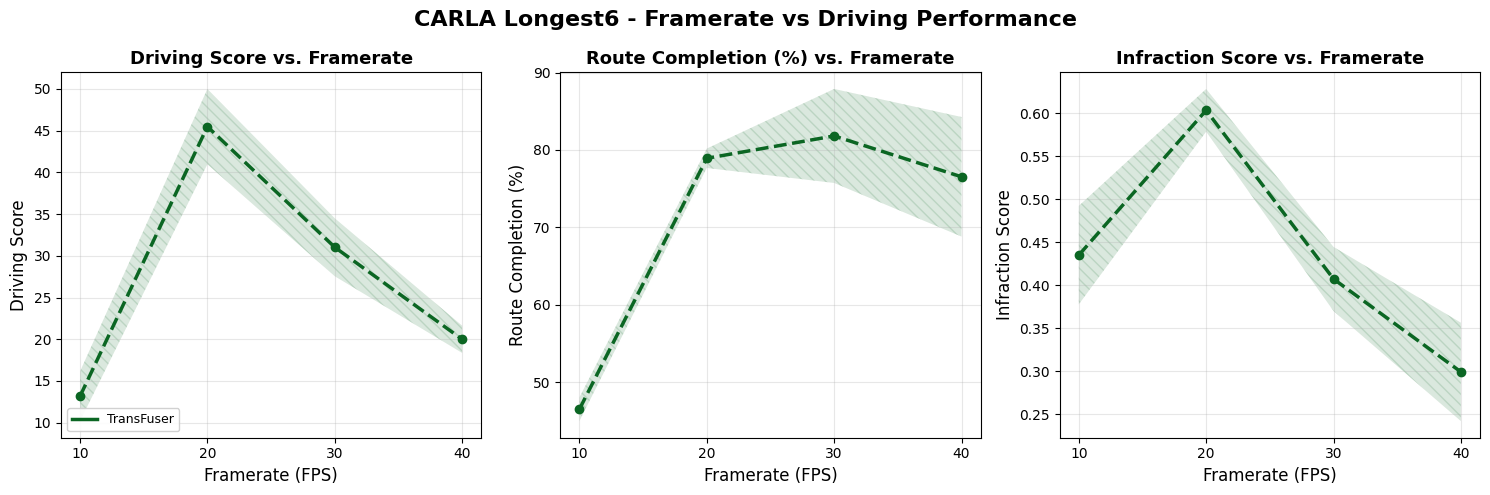

In [8]:
plot_carla_results(df, "CARLA Longest6 - Framerate vs Driving Performance")

# Adjust layout and show
plt.tight_layout()
# plt.subplots_adjust(top=0.93)
plt.show()